In [1]:
from dcms import Dcm, Linear
import numpy as np
dcm = Dcm()
lin = Linear()
# Doing cross product using the tilde matrix

# Calculating the normal way (numpy)
r1 = lin.vector(1,2,3)
r2 = lin.vector(3,2,1)
cp = np.cross(r1,r2)
print(f'normal cross product = {cp}')

# Calculating using tilde matrix
rtilde = lin.tilde(r1)
cp_tilde = rtilde@r2
print(f'tilde cross product = {cp_tilde}')

normal cross product = [-4  8 -4]
tilde cross product = [-4  8 -4]


In [ ]:
#Using the linear package to find DCM derivatives
BN = np.array([[-0.87097, 0.45161, 0.19355],
               [-0.19355, -0.67742, 0.70968],
               [0.45161, 0.58065, 0.67742]])
omega = lin.vector(0.1,0.2,0.3)

dcm_rate = -lin.tilde(omega)@BN
print(dcm_rate)

[[-0.148387 -0.319356  0.07742 ]
 [ 0.306452 -0.077418  0.009677]
 [-0.154839  0.158064 -0.032258]]


In [5]:
import numpy as np
from dcms import Dcm
dcm = Dcm()

# Creating DCMs and going back and forth with EAs
mat313 = dcm.dcm_313(4,9,12,deg=True)
print(f'DCM = {mat313}')
Omega, i , omega = dcm.inv_313(mat313,deg=True)
print(f'Omega = {round(Omega,4)}, i = {round(i,4)}, omega = {round(omega,4)} deg')

DCM = [[ 0.96144025  0.27308385  0.03252455]
 [-0.27479731  0.94924841  0.153016  ]
 [ 0.01091232 -0.1560534   0.98768834]]
Omega = 4.0, i = 9.0, omega = 12.0 deg


In [10]:
import numpy as np
from dcms import Dcm

dcm = Dcm()

# Taking Euler angles in 321 and finding associated 313
theta1 = -10
theta2 = 10
theta3 = 20

M321 = dcm.dcm_321(theta1,theta2,theta3,True)
Omega,i,omega = dcm.inv_313(M321,False)
print(f'Omega = {round(Omega,4)}, i = {round(i,4)}, omega = {round(omega,4)} rad')
M313 = dcm.dcm_313(Omega,i,omega,False)
print(f'\nM321 = {M321}, \nM313 = {M313}')
print('')
print(f'dM = {M313 - M321}')

Omega = 2.7129, i = 0.2462, omega = -2.3485 rad

M321 = [[ 0.92541658  0.33682409 -0.17364818]
 [-0.36515929  0.91510341 -0.17101007]
 [ 0.10130573  0.2216648   0.96984631]], 
M313 = [[ 0.92541658  0.33682409 -0.17364818]
 [-0.36515929  0.91510341 -0.17101007]
 [ 0.10130573  0.2216648   0.96984631]]

dM = [[ 1.11022302e-16 -2.77555756e-16 -2.77555756e-16]
 [ 2.77555756e-16  1.11022302e-16 -3.33066907e-16]
 [ 2.08166817e-16  3.60822483e-16  0.00000000e+00]]


In [5]:
from dcms import Dcm

dcm = Dcm()

BN = dcm.dcm_321(30,20,10,True)
print(BN)
RN = dcm.dcm_321(5,5,-5,True)
BR = BN@np.transpose(RN)
alpha,beta,gamma = dcm.inv_321(BR,True)
print(f'alpha = {round(alpha,4)}, beta = {round(beta,4)}, gamma = {round(gamma,4)} rad')


[[ 0.92541658  0.16317591 -0.34202014]
 [ 0.01802831  0.88256412  0.46984631]
 [ 0.37852231 -0.44096961  0.81379768]]
alpha = 13.2238, beta = 16.3683, gamma = 23.6176 rad


In [15]:
dcm = Dcm()

BN = dcm.dcm_321(60,-45,30,True)
FN = dcm.dcm_321(-15,25,10,True)
print(f'BN = {BN}')
print(f'FN = {FN}\n')

BF = BN@np.transpose(FN)
print(f'BF = {BF}\n')

psi,theta,phi = dcm.inv_321(BF,True)
print(f'psi = {psi}, theta = {theta}, phi = {phi}')

BN = [[ 0.61237244  0.35355339  0.70710678]
 [-0.78033009  0.12682648  0.61237244]
 [ 0.12682648 -0.9267767   0.35355339]]
FN = [[ 0.89253894  0.1573787  -0.42261826]
 [-0.27545116  0.93225732 -0.23456972]
 [ 0.35707269  0.3257733   0.8754261 ]]

BF = [[ 0.30337177 -0.0049418   0.95285946]
 [-0.93531497  0.18953372  0.29876893]
 [-0.18207545 -0.98186178  0.05287704]]

psi = -0.9332418570522777, theta = -72.33734718695746, phi = 79.96354675311211


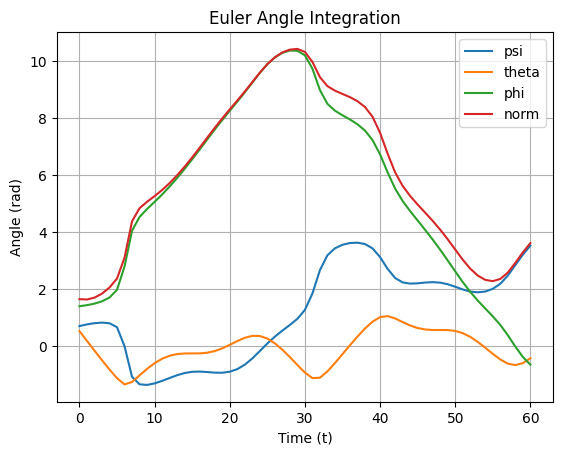

6.105089136926999


In [4]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# 1. Define the ODE function
def B(y):
    psi = y[0]
    theta = y[1]
    phi = y[2]
    M = 1/np.cos(theta)*np.array([[0,np.sin(phi),np.cos(phi)],
                    [0,np.cos(phi)*np.cos(theta),-np.sin(phi)*np.cos(theta)],
                    [np.cos(theta),np.sin(phi)*np.sin(theta),np.cos(phi)*np.sin(theta)]])
    return M
def ea_dot(t, y):
    """
    """
    omega_dot =20*np.pi/180* np.array([np.sin(0.1*t),0.01,np.cos(0.1*t)])
    ydot = B(y)@omega_dot
    return ydot

# 2. Specify the time span and initial conditions
t_span = (0, 60)  
tval = np.linspace(0,60,61)
y0 = [40,30,80]        # Initial conditions for y[0] and y[1]
y0 = [y*np.pi/180 for y in y0]

# 3. Solve the ODE using solve_ivp with the default 'RK45' method
sol = solve_ivp(fun=ea_dot, t_span=t_span, y0=y0, method='RK45',t_eval=tval)

# 4. Access and plot the results
t = sol.t
y = sol.y.T # Transpose y to have columns as variables

length = [np.linalg.norm(y[i,:]) for i in range(len(y))]
plt.plot(t, y[:, 0], label='psi')
plt.plot(t, y[:, 1], label='theta')
plt.plot(t, y[:, 2], label='phi')
plt.plot(t,length,label='norm')
plt.xlabel('Time (t)')
plt.ylabel('Angle (rad)')
plt.title('Euler Angle Integration')
plt.legend()
plt.grid(True)
plt.show()

print(length[42])